In [1]:
import pandas as pd

In [2]:
metadata = pd.read_csv('C:/Users/julia23006/OneDrive - ILUM ESCOLA DE CIÊNCIA/Documentos/Ilum/TCC/metadata/sample_metadata.tsv', sep='\t')
metadata

,sample_id,group,study_id,disease_group
0,SRR6784522,cfs,cfs_nagy2017,CFS
1,SRR6784544,cfs,cfs_nagy2017,CFS
2,SRR6784404,cfs,cfs_nagy2017,CFS
3,SRR6784532,cfs,cfs_nagy2017,CFS
4,SRR6784552,cfs,cfs_nagy2017,CFS
...,...,...,...,...
181,SRR6784540,controle,cfs_nagy2017,CFS
182,SRR6784567,controle,cfs_nagy2017,CFS
183,SRR8556969,controle,fbm_minerbi2019,FBM
184,ERR911991,controle,enx_chen2020,ENX


In [3]:
taxonomia = pd.read_csv('C:/Users/julia23006/OneDrive - ILUM ESCOLA DE CIÊNCIA/Documentos/Ilum/TCC/taxonomia/metadata/taxonomia_bruta_metadata_corrigida.csv')
taxonomia_certo = taxonomia.dropna(axis=1).rename({'Unnamed: 0': 'sample_id'}, axis=1)
taxonomia_metadata = taxonomia_certo.merge(metadata[['sample_id', 'group']], on='sample_id', how='left')
taxonomia_metadata

,sample_id,Abditibacteriaceae bacterium,Abditibacteriota bacterium,Absicoccus porci,Absiella sp. AM09-45,Absiella sp. AM09-50,Absiella sp. AM10-20,Absiella sp. AM22-9,Absiella sp. AM27-20,Absiella sp. AM29-15,...,Toxocara canis,Treponema primitia,Treponema zioleckii,Trichococcus palustris,Trichococcus sp. K1Tr,Ureaplasma sp.,Vagococcus fessus,Vallitalea okinawensis,Vallitaleaceae bacterium,group
0,SRR6784522,0,0,0,41,0,40,11,24,100,...,0,0,0,0,0,0,0,0,0,cfs
1,SRR6784544,0,0,0,314,16,1039,46,130,353,...,0,0,0,0,0,0,0,0,0,cfs
2,SRR6784404,0,0,685,26,4,841,14,68,283,...,0,0,0,0,0,0,0,0,0,cfs
3,SRR6784532,0,0,0,213,0,1738,13,79,82,...,0,0,0,0,0,0,0,0,0,cfs
4,SRR6784552,0,0,0,857,0,95,23,124,48,...,0,0,0,0,0,0,0,0,0,cfs
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181,SRR8556948,0,0,0,1,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,fbm
182,SRR8556919,0,0,0,1,0,8,0,0,0,...,0,0,0,0,0,0,0,0,0,fbm
183,SRR8556885,0,0,0,9,0,0,0,0,0,...,0,0,0,2,0,0,0,0,0,fbm
184,SRR8556994,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,fbm


### Controle e FBM

In [4]:
taxo_fbm_controle = taxonomia_metadata[taxonomia_metadata['group'].isin(['fbm', 'controle'])]
taxo_fbm_controle

,sample_id,Abditibacteriaceae bacterium,Abditibacteriota bacterium,Absicoccus porci,Absiella sp. AM09-45,Absiella sp. AM09-50,Absiella sp. AM10-20,Absiella sp. AM22-9,Absiella sp. AM27-20,Absiella sp. AM29-15,...,Toxocara canis,Treponema primitia,Treponema zioleckii,Trichococcus palustris,Trichococcus sp. K1Tr,Ureaplasma sp.,Vagococcus fessus,Vallitalea okinawensis,Vallitaleaceae bacterium,group
45,SRR24907908,0,0,0,0,47,13,7,6,58,...,0,0,0,0,0,0,0,0,0,controle
46,ERR911979,0,0,9,51,633,330,109,187,806,...,0,0,0,0,0,0,0,0,0,controle
47,ERR911956,0,0,1,8,291,118,224,188,896,...,0,0,0,0,0,0,0,0,0,controle
48,SRR6784564,0,0,0,18,17,33,21,27,135,...,0,0,0,0,0,0,0,0,0,controle
49,SRR6784403,0,468,0,116,11,1648,64,38,243,...,0,0,0,0,0,0,0,0,0,controle
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181,SRR8556948,0,0,0,1,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,fbm
182,SRR8556919,0,0,0,1,0,8,0,0,0,...,0,0,0,0,0,0,0,0,0,fbm
183,SRR8556885,0,0,0,9,0,0,0,0,0,...,0,0,0,2,0,0,0,0,0,fbm
184,SRR8556994,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,fbm


#### Filtragem

In [5]:
taxo_fc_cols = [c for c in taxo_fbm_controle.columns if c not in ['sample_id', 'group']]
taxo_fc_rel = taxo_fbm_controle.copy()
taxo_fc_rel[taxo_fc_cols] = taxo_fc_rel[taxo_fc_cols].div(taxo_fc_rel[taxo_fc_cols].sum(axis=1), axis=0)

limite_abund = 0.0001 # 0.01% em fração
limite_amostras = 0.60 # 20% das amostras

filtro_taxo_fc = (taxo_fc_rel[taxo_fc_cols] > limite_abund).sum(axis=0) >= (len(taxo_fc_rel) * limite_amostras)
cols_taxo_fc_keep = filtro_taxo_fc[filtro_taxo_fc].index.tolist()
taxo_fc_filtrados = taxo_fc_rel.loc[:, cols_taxo_fc_keep] if cols_taxo_fc_keep else taxo_fc_rel.iloc[:, 0:0]
taxo_fc_filtrado = pd.concat([taxo_fbm_controle[['sample_id', 'group']].reset_index(drop=True),
                            taxo_fc_filtrados.reset_index(drop=True)], axis=1)

print(f"Táxons antes: {len(taxo_fc_cols)} e depois: {len(cols_taxo_fc_keep)}")

abund_taxo_fc_antes = taxo_fc_rel[taxo_fc_cols].sum(axis=1).mean() * 100
abund_taxo_fc_depois = taxo_fc_filtrados.sum(axis=1).mean() * 100

print(f"Abundância média táxons antes: {abund_taxo_fc_antes:.4f}%")
print(f"Abundância média táxons depois: {abund_taxo_fc_depois:.4f}%")
print(f"Percentual de abundância táxons retido: {(abund_taxo_fc_depois / abund_taxo_fc_antes * 100):.2f}%\n")

Táxons antes: 9124 e depois: 178
Abundância média táxons antes: 100.0000%
Abundância média táxons depois: 86.5446%
Percentual de abundância táxons retido: 86.54%



#### Salvando tabela bruta filtrada e relativa filtrada

In [6]:
taxo_fc_bruto_filtrado = pd.concat([taxo_fbm_controle[['sample_id', 'group']], taxo_fbm_controle[cols_taxo_fc_keep]], axis=1)
taxo_fc_filtrado.to_csv("taxo_fc_rel_filtrado.csv", index=False)
taxo_fc_bruto_filtrado.to_csv("taxo_fc_bruto_filtrado.csv", index=False)

### Controle e Enxaqueca

In [7]:
taxo_enx_controle = taxonomia_metadata[taxonomia_metadata['group'].isin(['enx', 'controle'])]
taxo_enx_controle

,sample_id,Abditibacteriaceae bacterium,Abditibacteriota bacterium,Absicoccus porci,Absiella sp. AM09-45,Absiella sp. AM09-50,Absiella sp. AM10-20,Absiella sp. AM22-9,Absiella sp. AM27-20,Absiella sp. AM29-15,...,Toxocara canis,Treponema primitia,Treponema zioleckii,Trichococcus palustris,Trichococcus sp. K1Tr,Ureaplasma sp.,Vagococcus fessus,Vallitalea okinawensis,Vallitaleaceae bacterium,group
45,SRR24907908,0,0,0,0,47,13,7,6,58,...,0,0,0,0,0,0,0,0,0,controle
46,ERR911979,0,0,9,51,633,330,109,187,806,...,0,0,0,0,0,0,0,0,0,controle
47,ERR911956,0,0,1,8,291,118,224,188,896,...,0,0,0,0,0,0,0,0,0,controle
48,SRR6784564,0,0,0,18,17,33,21,27,135,...,0,0,0,0,0,0,0,0,0,controle
49,SRR6784403,0,468,0,116,11,1648,64,38,243,...,0,0,0,0,0,0,0,0,0,controle
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135,ERR912113,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,enx
136,ERR912053,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,enx
137,ERR912054,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,enx
138,ERR912063,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,enx


In [8]:
taxo_ec_cols = [c for c in taxo_enx_controle.columns if c not in ['sample_id', 'group']]
taxo_ec_rel = taxo_enx_controle.copy()
taxo_ec_rel[taxo_ec_cols] = taxo_ec_rel[taxo_ec_cols].div(taxo_ec_rel[taxo_ec_cols].sum(axis=1), axis=0)

limite_abund = 0.0001 # 0.01% em fração
limite_amostras = 0.60 # 20% das amostras

filtro_taxo_ec = (taxo_ec_rel[taxo_ec_cols] > limite_abund).sum(axis=0) >= (len(taxo_ec_rel) * limite_amostras)
cols_taxo_ec_keep = filtro_taxo_ec[filtro_taxo_ec].index.tolist()
taxo_ec_filtrados = taxo_ec_rel.loc[:, cols_taxo_ec_keep] if cols_taxo_ec_keep else taxo_ec_rel.iloc[:, 0:0]
taxo_ec_filtrado = pd.concat([taxo_enx_controle[['sample_id', 'group']].reset_index(drop=True),
                            taxo_ec_filtrados.reset_index(drop=True)], axis=1)

print(f"Táxons antes: {len(taxo_ec_cols)} e depois: {len(cols_taxo_ec_keep)}")

abund_taxo_ec_antes = taxo_ec_rel[taxo_ec_cols].sum(axis=1).mean() * 100
abund_taxo_ec_depois = taxo_ec_filtrados.sum(axis=1).mean() * 100

print(f"Abundância média táxons antes: {abund_taxo_ec_antes:.4f}%")
print(f"Abundância média táxons depois: {abund_taxo_ec_depois:.4f}%")
print(f"Percentual de abundância táxons retido: {(abund_taxo_ec_depois / abund_taxo_ec_antes * 100):.2f}%\n")

Táxons antes: 9124 e depois: 101
Abundância média táxons antes: 100.0000%
Abundância média táxons depois: 71.6669%
Percentual de abundância táxons retido: 71.67%



#### Salvando tabela bruta filtrada e relativa filtrada

In [9]:
taxo_ec_bruto_filtrado = pd.concat([taxo_enx_controle[['sample_id', 'group']], taxo_enx_controle[cols_taxo_ec_keep]], axis=1)
taxo_ec_filtrado.to_csv("taxo_ec_rel_filtrado.csv", index=False)
taxo_ec_bruto_filtrado.to_csv("taxo_ec_bruto_filtrado.csv", index=False)

### Controle e cfs

In [10]:
taxo_cfs_controle = taxonomia_metadata[taxonomia_metadata['group'].isin(['cfs', 'controle'])]
taxo_cfs_controle

,sample_id,Abditibacteriaceae bacterium,Abditibacteriota bacterium,Absicoccus porci,Absiella sp. AM09-45,Absiella sp. AM09-50,Absiella sp. AM10-20,Absiella sp. AM22-9,Absiella sp. AM27-20,Absiella sp. AM29-15,...,Toxocara canis,Treponema primitia,Treponema zioleckii,Trichococcus palustris,Trichococcus sp. K1Tr,Ureaplasma sp.,Vagococcus fessus,Vallitalea okinawensis,Vallitaleaceae bacterium,group
0,SRR6784522,0,0,0,41,0,40,11,24,100,...,0,0,0,0,0,0,0,0,0,cfs
1,SRR6784544,0,0,0,314,16,1039,46,130,353,...,0,0,0,0,0,0,0,0,0,cfs
2,SRR6784404,0,0,685,26,4,841,14,68,283,...,0,0,0,0,0,0,0,0,0,cfs
3,SRR6784532,0,0,0,213,0,1738,13,79,82,...,0,0,0,0,0,0,0,0,0,cfs
4,SRR6784552,0,0,0,857,0,95,23,124,48,...,0,0,0,0,0,0,0,0,0,cfs
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89,SRR6784540,0,0,0,46,77,39,274,535,1062,...,0,0,0,0,0,0,0,0,0,controle
90,SRR6784567,0,0,2,5,6,40,75,45,270,...,0,0,0,0,0,0,0,0,0,controle
91,SRR8556969,0,0,0,31,0,4,2,12,53,...,0,0,0,0,0,0,0,0,0,controle
92,ERR911991,0,0,1,15,41,56,44,175,353,...,0,0,0,0,0,0,0,0,0,controle


In [11]:
taxo_cc_cols = [c for c in taxo_cfs_controle.columns if c not in ['sample_id', 'group']]
taxo_cc_rel = taxo_cfs_controle.copy()
taxo_cc_rel[taxo_cc_cols] = taxo_cc_rel[taxo_cc_cols].div(taxo_cc_rel[taxo_cc_cols].sum(axis=1), axis=0)

limite_abund = 0.0001 # 0.01% em fração
limite_amostras = 0.60 # 20% das amostras

filtro_taxo_cc = (taxo_cc_rel[taxo_cc_cols] > limite_abund).sum(axis=0) >= (len(taxo_cc_rel) * limite_amostras)
cols_taxo_cc_keep = filtro_taxo_cc[filtro_taxo_cc].index.tolist()
taxo_cc_filtrados = taxo_cc_rel.loc[:, cols_taxo_cc_keep] if cols_taxo_cc_keep else taxo_cc_rel.iloc[:, 0:0]
taxo_cc_filtrado = pd.concat([taxo_cfs_controle[['sample_id', 'group']].reset_index(drop=True),
                            taxo_cc_filtrados.reset_index(drop=True)], axis=1)

print(f"Táxons antes: {len(taxo_cc_cols)} e depois: {len(cols_taxo_cc_keep)}")

abund_taxo_cc_antes = taxo_cc_rel[taxo_cc_cols].sum(axis=1).mean() * 100
abund_taxo_cc_depois = taxo_cc_filtrados.sum(axis=1).mean() * 100

print(f"Abundância média táxons antes: {abund_taxo_cc_antes:.4f}%")
print(f"Abundância média táxons depois: {abund_taxo_cc_depois:.4f}%")
print(f"Percentual de abundância táxons retido: {(abund_taxo_cc_depois / abund_taxo_cc_antes * 100):.2f}%\n")

Táxons antes: 9124 e depois: 181
Abundância média táxons antes: 100.0000%
Abundância média táxons depois: 84.7808%
Percentual de abundância táxons retido: 84.78%



#### Salvando tabela bruta filtrada e relativa filtrada

In [12]:
taxo_cc_bruto_filtrado = pd.concat([taxo_cfs_controle[['sample_id', 'group']], taxo_cfs_controle[cols_taxo_cc_keep]], axis=1)
taxo_cc_filtrado.to_csv("taxo_cc_rel_filtrado.csv", index=False)
taxo_cc_bruto_filtrado.to_csv("taxo_cc_bruto_filtrado.csv", index=False)

In [13]:
teste = pd.read_csv('taxo_cc_rel_filtrado.csv')
teste

,sample_id,group,Acetatifactor sp.,Acutalibacteraceae bacterium,Agathobacter,Agathobacter rectalis,Agathobacter rectalis ATCC 33656,Agathobacter sp.,Akkermansia,Akkermansia muciniphila,...,Roseburia inulinivorans,Roseburia porci,Ruminococcaceae bacterium OttesenSCG-928-L11,Ruminococcus bicirculans (ex Wegman et al. 2014),Ruminococcus hominis,Ruminococcus turbiniformis,Segatella,Streptomyces sp. DSM 41524,Subdoligranulum sp. AF14-43,Tannockella kyphosi
0,SRR6784522,cfs,0.000059,0.002204,0.001205,0.002317,0.000266,0.000339,0.000004,0.000180,...,0.000038,0.000167,0.002562,0.003847,0.001845,0.000213,0.021386,0.000074,0.000203,0.000200
1,SRR6784544,cfs,0.000370,0.000130,0.000197,0.001318,0.000111,0.000287,0.000577,0.000853,...,0.000057,0.000252,0.000116,0.000666,0.001347,0.001039,0.000194,0.001323,0.000541,0.001125
2,SRR6784404,cfs,0.002488,0.000151,0.013040,0.020962,0.002498,0.003138,0.001635,0.001294,...,0.000165,0.001806,0.008196,0.000304,0.009324,0.000259,0.262860,0.000340,0.000665,0.000657
3,SRR6784532,cfs,0.003624,0.000083,0.019882,0.033420,0.003677,0.005778,0.000018,0.000056,...,0.003333,0.012135,0.004529,0.004592,0.002786,0.000390,0.000429,0.002440,0.005627,0.001306
4,SRR6784552,cfs,0.001256,0.000290,0.001274,0.004703,0.000286,0.000592,0.000004,0.000044,...,0.000382,0.001833,0.000143,0.000580,0.000726,0.000503,0.001512,0.000084,0.000093,0.000611
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89,SRR6784540,controle,0.002772,0.000122,0.007901,0.014408,0.001548,0.002618,0.006275,0.013439,...,0.000601,0.001016,0.000083,0.000795,0.002477,0.000496,0.000719,0.002596,0.003413,0.002009
90,SRR6784567,controle,0.001789,0.000290,0.000786,0.002978,0.000174,0.001114,0.000007,0.000077,...,0.000200,0.002172,0.000379,0.000247,0.001686,0.000093,0.331930,0.000109,0.000164,0.000307
91,SRR8556969,controle,0.000154,0.003844,0.008539,0.014408,0.001741,0.003415,0.000071,0.000127,...,0.000086,0.000389,0.000957,0.001189,0.001665,0.000353,0.203349,0.001095,0.001075,0.000290
92,ERR911991,controle,0.002391,0.000200,0.002335,0.002601,0.000144,0.000845,0.000061,0.000023,...,0.000357,0.002668,0.002284,0.000538,0.000749,0.000078,0.000717,0.000282,0.000254,0.000460


### Plots

  Taxonomia: (94, 183) amostras, 181 táxons
  Taxonomia: (95, 103) amostras, 101 táxons
  Taxonomia: (95, 180) amostras, 178 táxons

Diversidade alfa


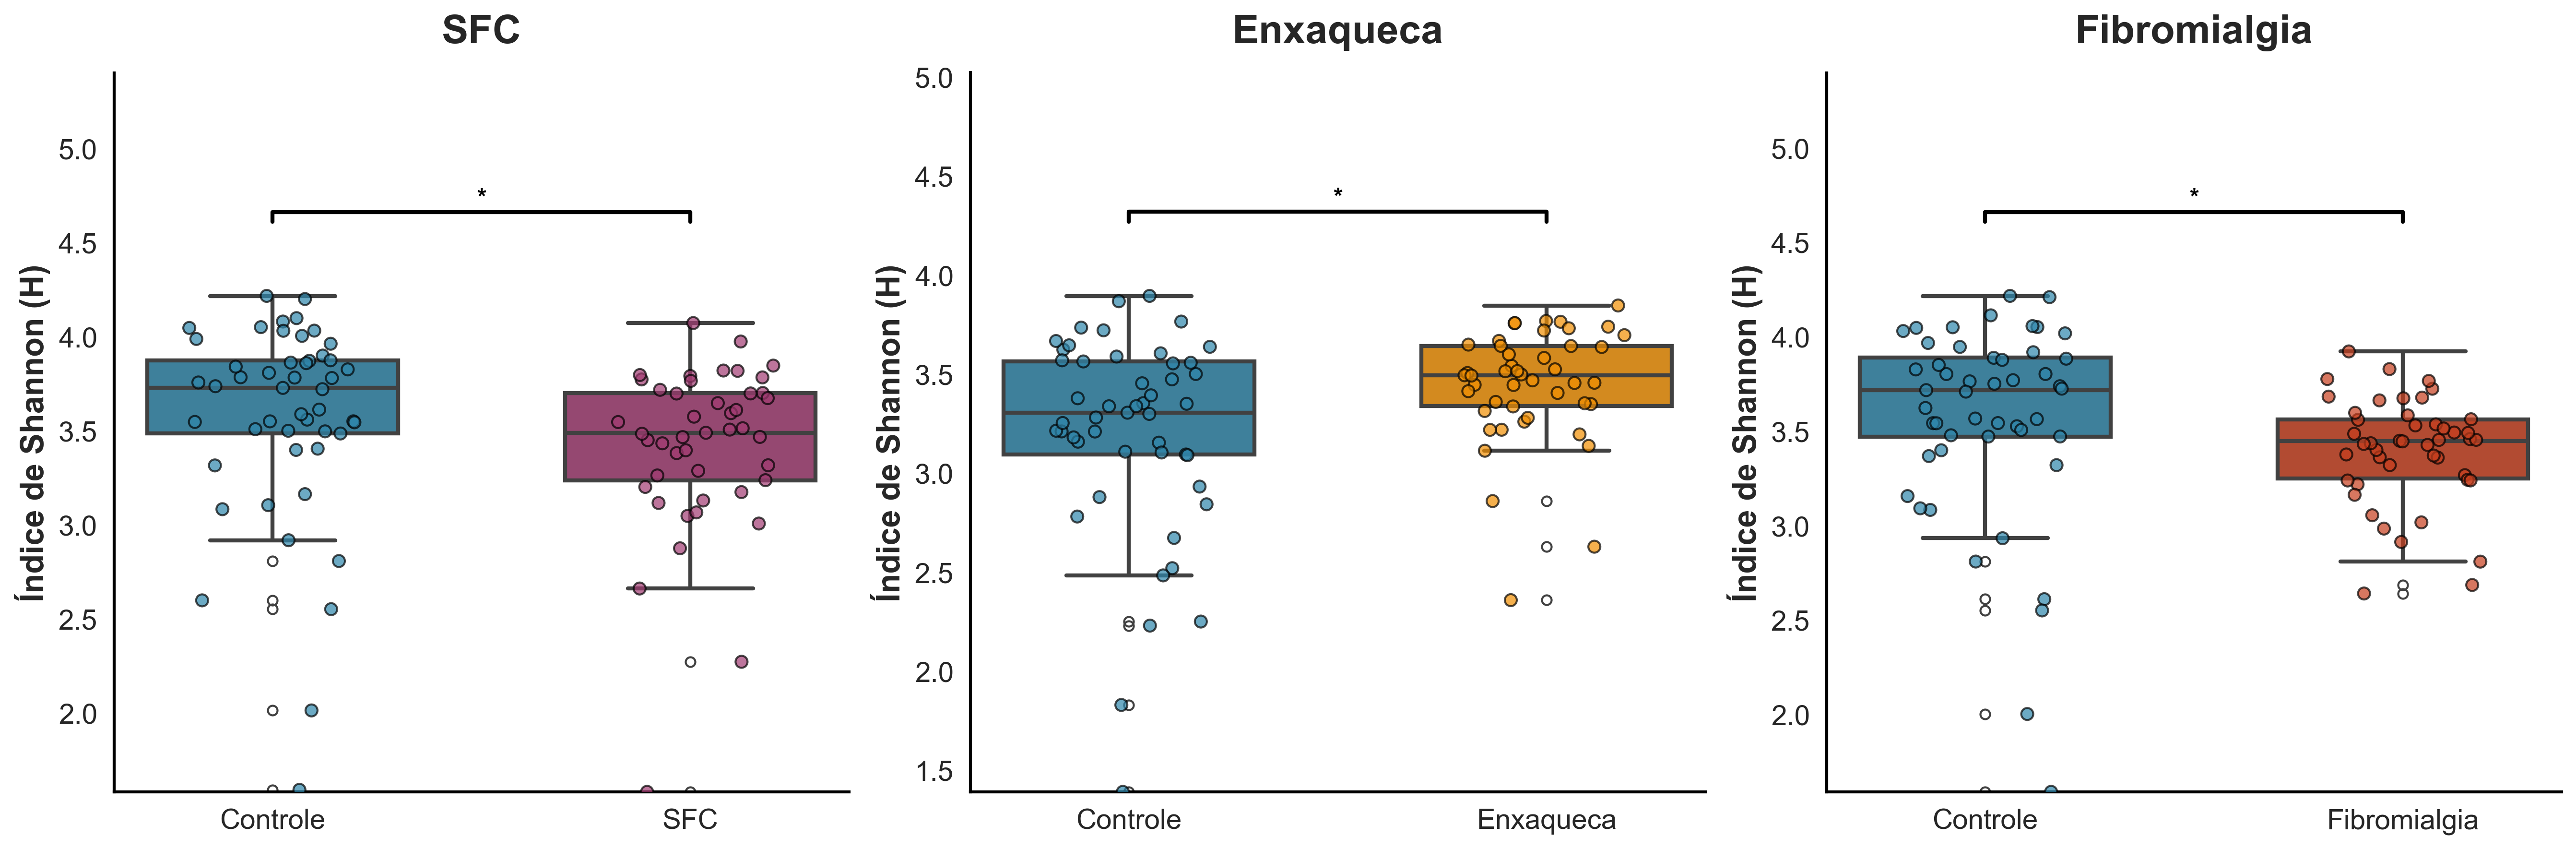


Diversidade beta


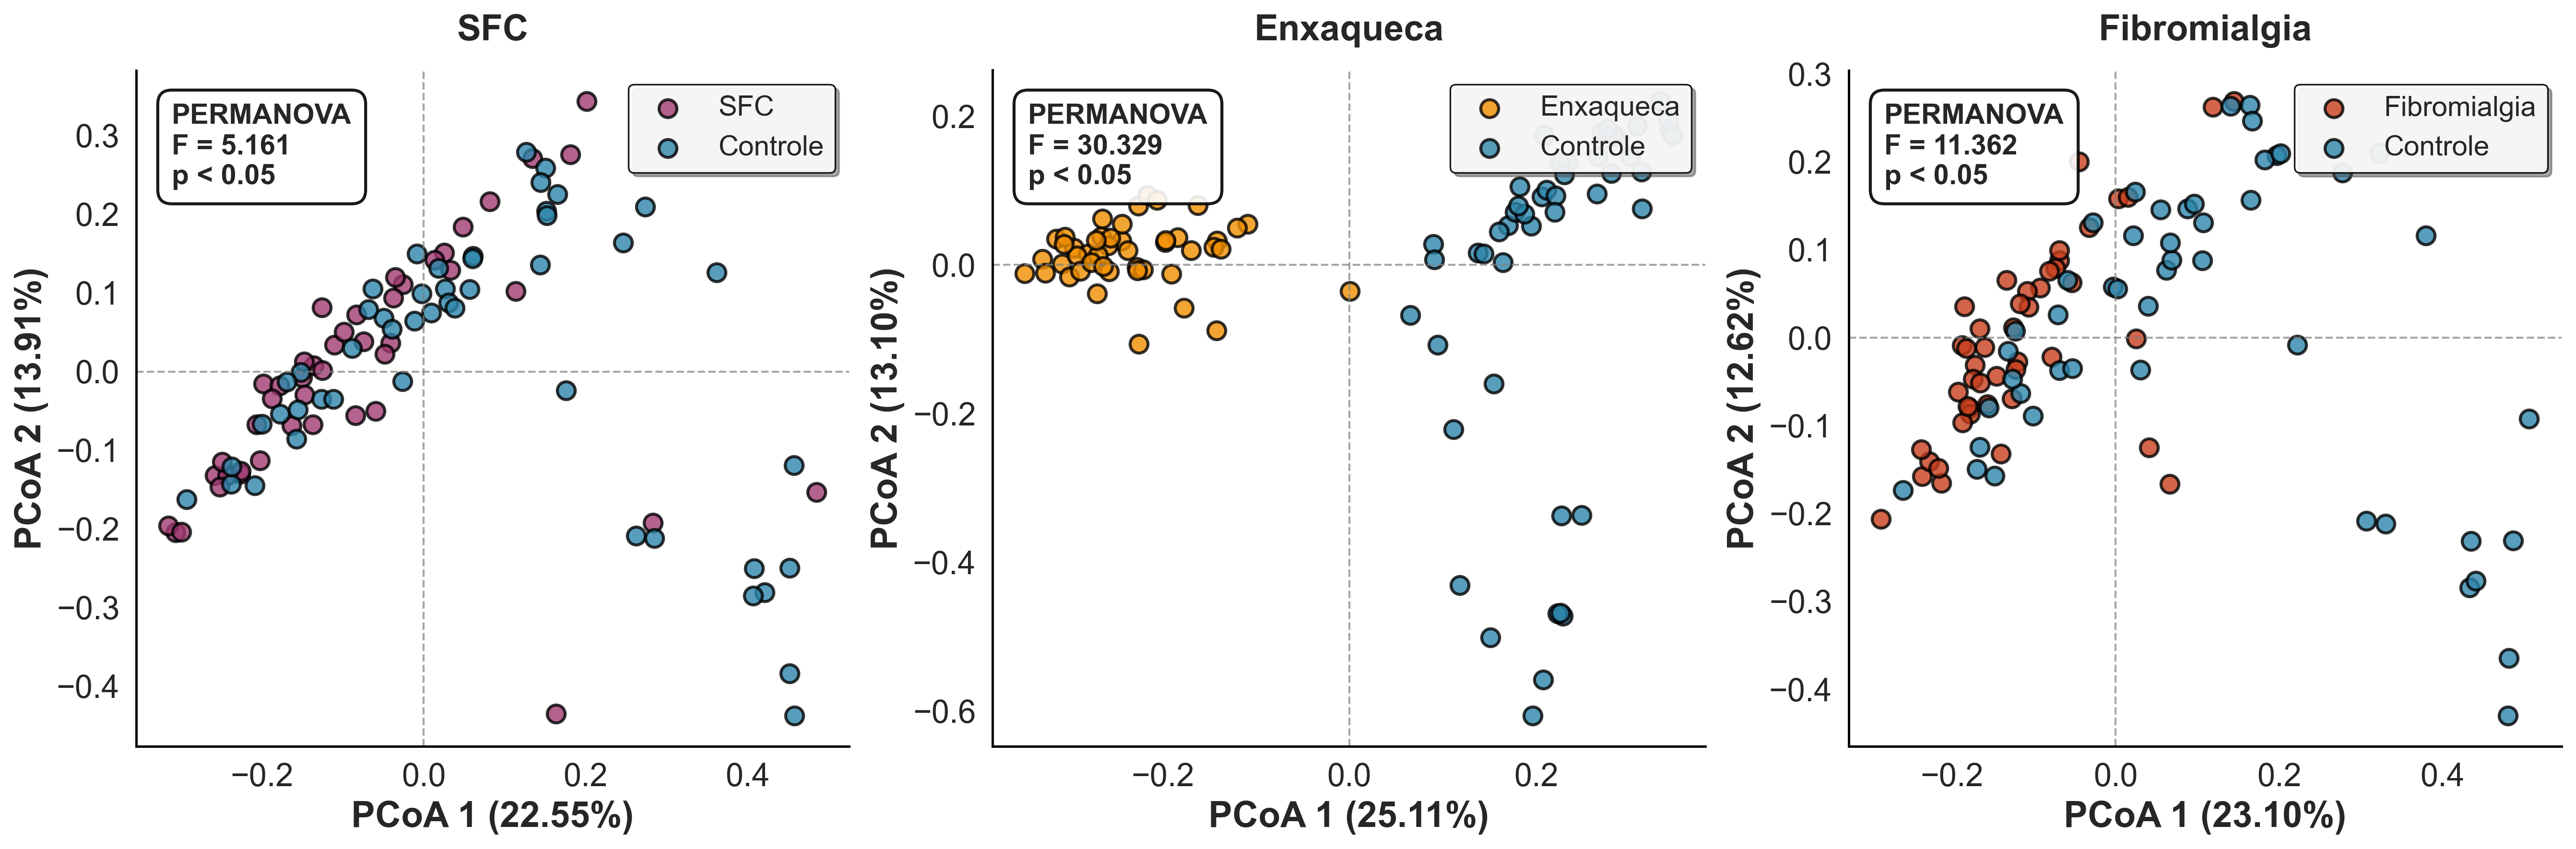


Resultados PERMANOVA (diversidade beta)):
SFC: F = 5.1608, p = 0.0010
Enxaqueca: F = 30.3292, p = 0.0010
Fibromialgia: F = 11.3616, p = 0.0010

Análise diferencial de táxons
Abundância diferencial
SFC
  Táxons comuns: 181
  Total de táxons testados: 181
  Táxons significativos (FDR < 0.05): 72


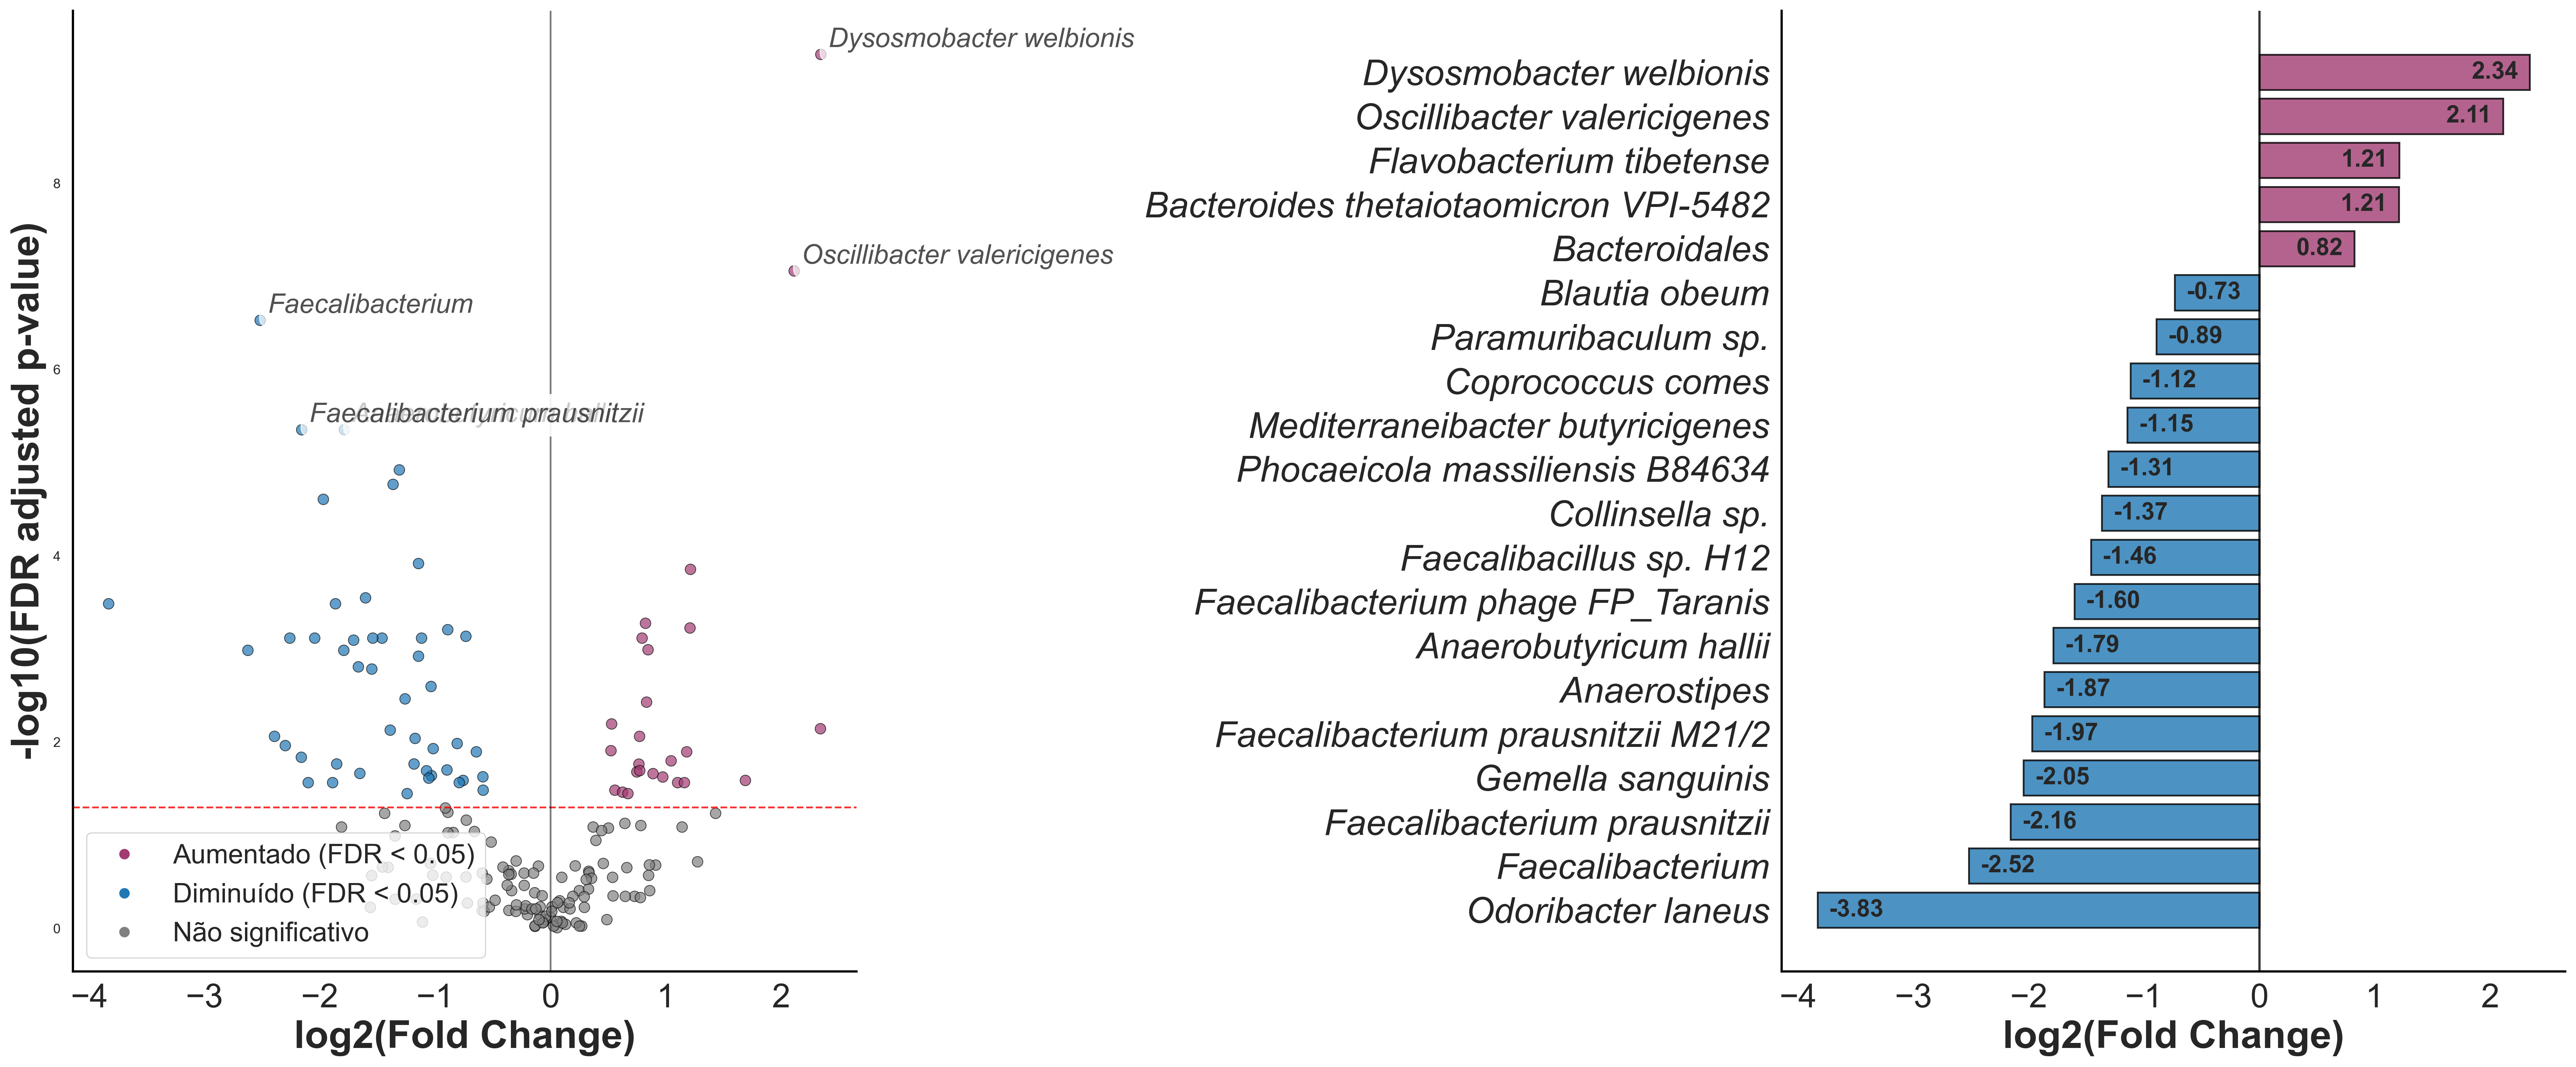

                                               Feature  log2_fold_change  \
101                            Dysosmobacter welbionis          2.344136   
135                        Oscillibacter valericigenes          2.113058   
110                                   Faecalibacterium         -2.517916   
18                              Anaerobutyricum hallii         -1.788164   
112                       Faecalibacterium prausnitzii         -2.157772   
153  Phocaeicola massiliensis B84634 = Timone 84634...         -1.311253   
94                                     Collinsella sp.         -1.365608   
113                 Faecalibacterium prausnitzii M21/2         -1.970414   
129                   Mediterraneibacter butyricigenes         -1.145177   
115                           Flavobacterium tibetense          1.213661   

        p_adj  
101  0.000000  
135  0.000000  
110  0.000000  
18   0.000004  
112  0.000004  
153  0.000012  
94   0.000017  
113  0.000025  
129  0.000121  
115

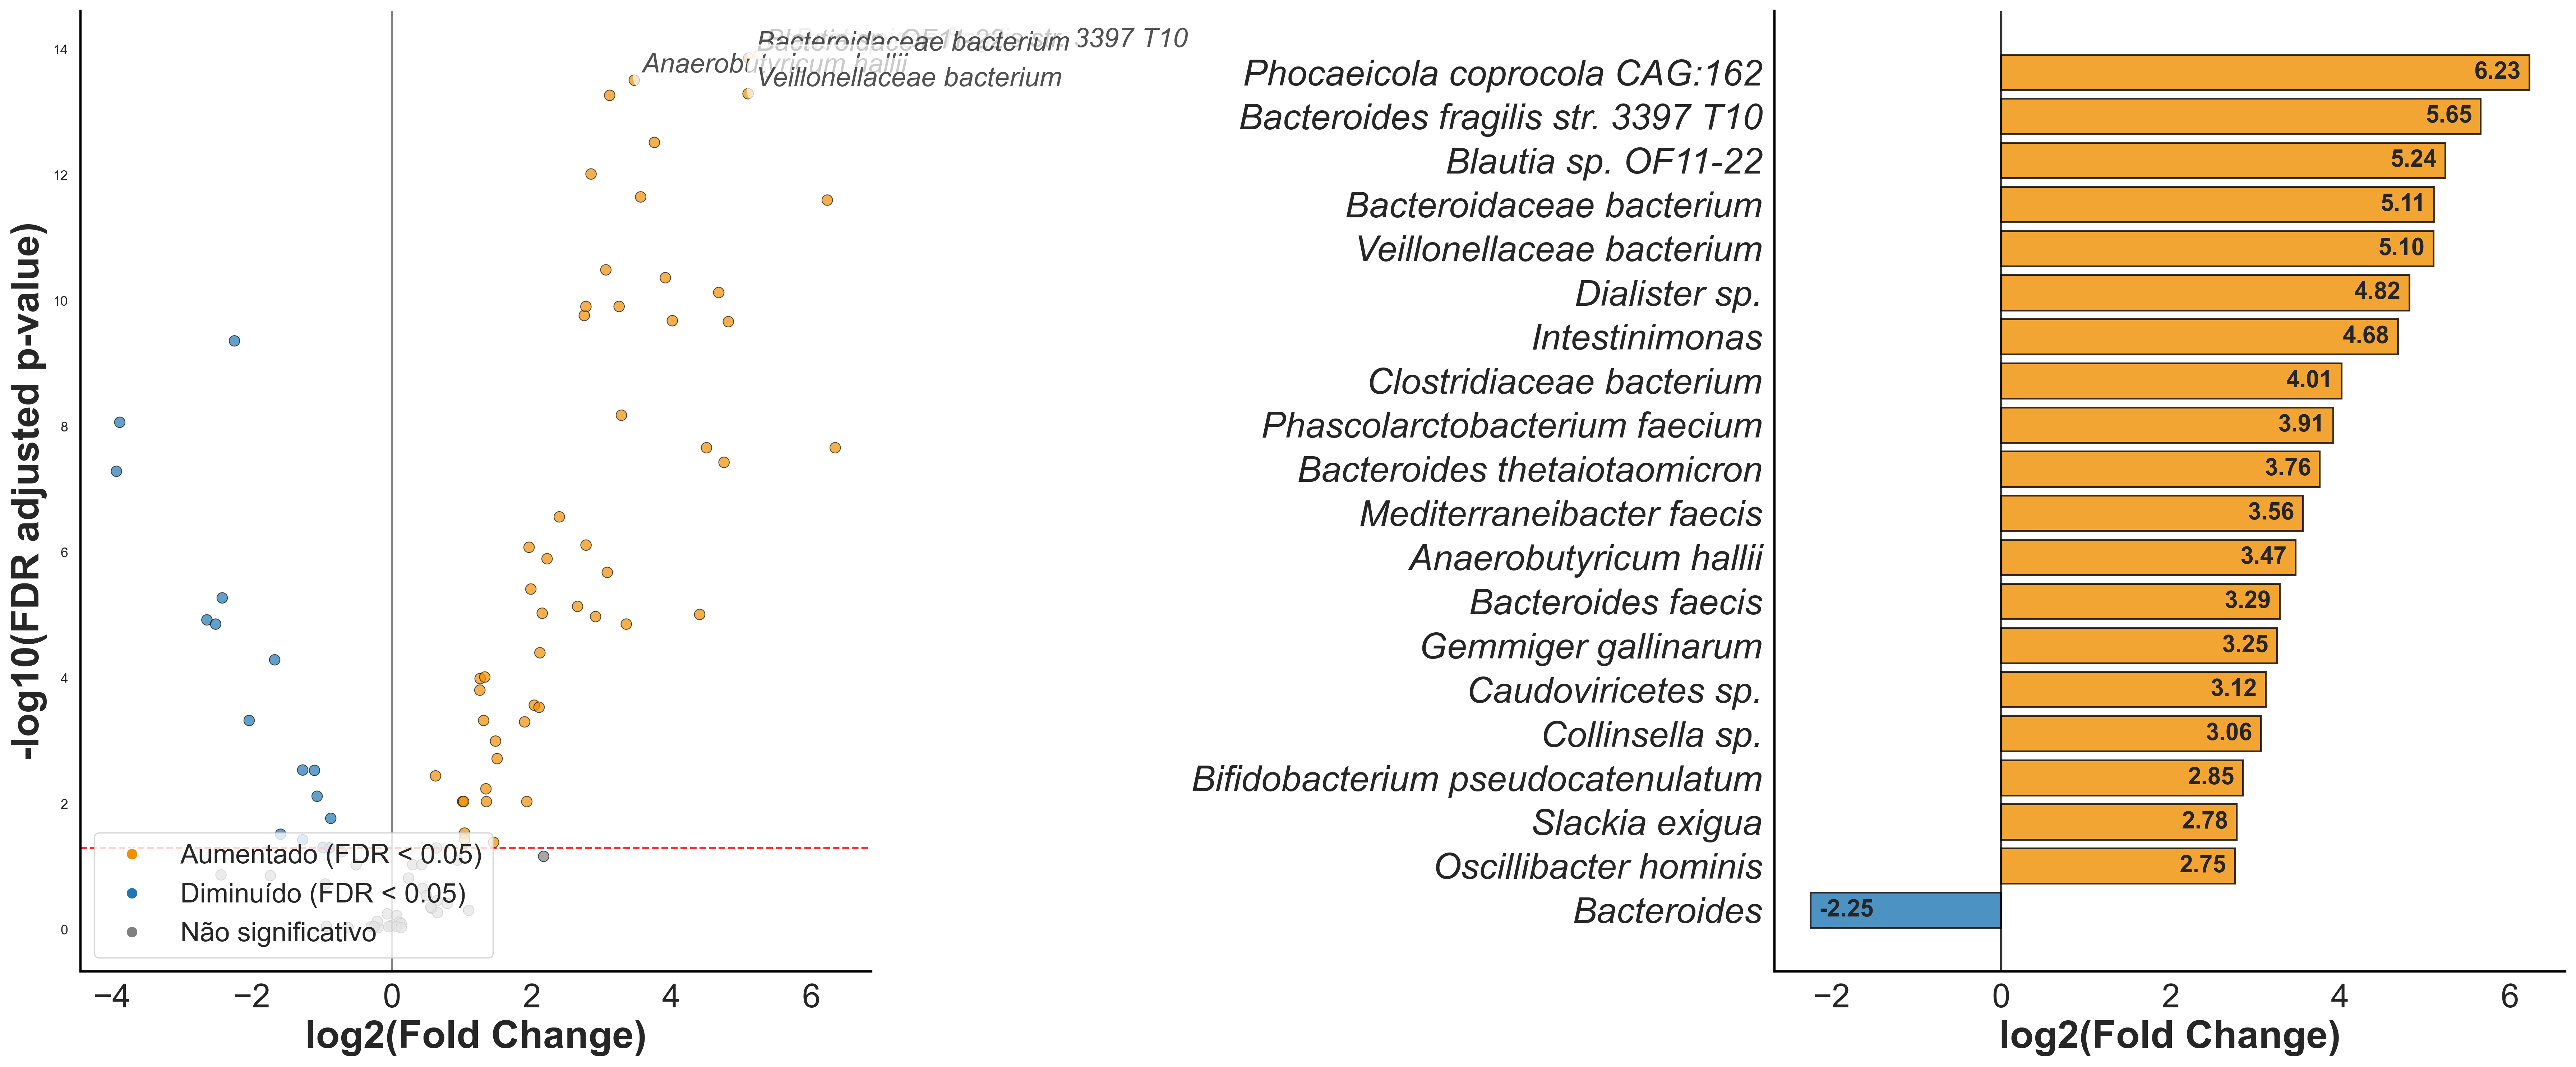

                                Feature  log2_fold_change  p_adj
27   Bacteroides fragilis str. 3397 T10          5.653149    0.0
41                  Blautia sp. OF11-22          5.240024    0.0
18             Bacteroidaceae bacterium          5.105165    0.0
11               Anaerobutyricum hallii          3.469631    0.0
100           Veillonellaceae bacterium          5.097226    0.0
44                   Caudoviricetes sp.          3.117747    0.0
31         Bacteroides thetaiotaomicron          3.757030    0.0
37    Bifidobacterium pseudocatenulatum          2.851254    0.0
73            Mediterraneibacter faecis          3.560966    0.0
83        Phocaeicola coprocola CAG:162          6.229841    0.0
Fibromialgia
  Táxons comuns: 178
  Total de táxons testados: 178
  Táxons significativos (FDR < 0.05): 94


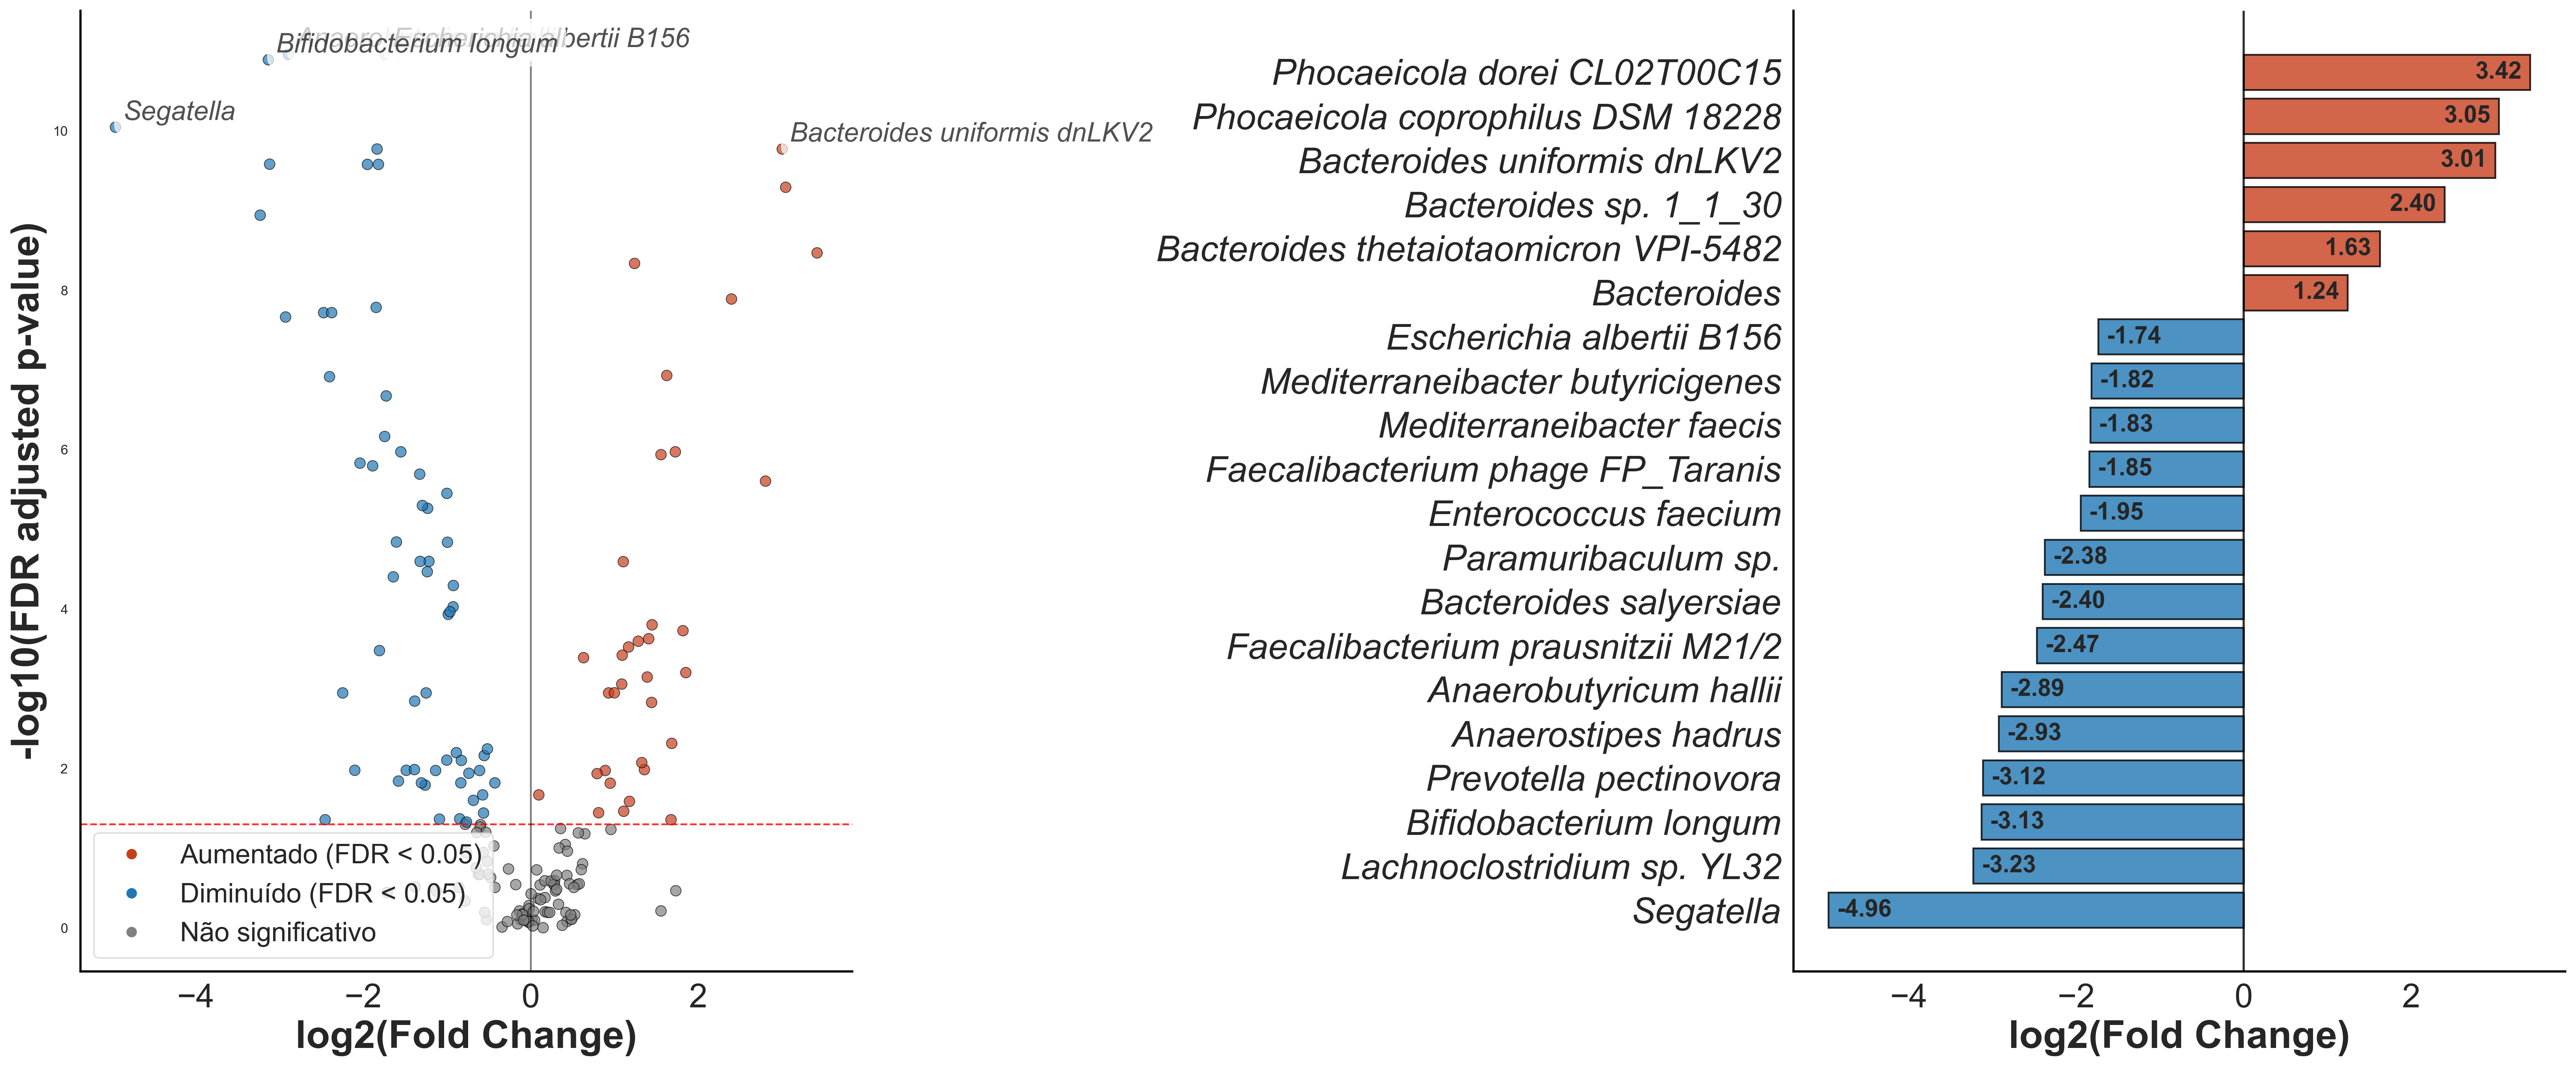

                                           Feature  log2_fold_change  p_adj
19                          Anaerobutyricum hallii         -2.892165    0.0
102                      Escherichia albertii B156         -1.738140    0.0
72                          Bifidobacterium longum         -3.132196    0.0
173                                      Segatella         -4.958524    0.0
65                    Bacteroides uniformis dnLKV2          3.005791    0.0
126                      Mediterraneibacter faecis         -1.833888    0.0
159                         Prevotella pectinovora         -3.117258    0.0
101                           Enterococcus faecium         -1.949166    0.0
125               Mediterraneibacter butyricigenes         -1.817688    0.0
147  Phocaeicola coprophilus DSM 18228 = JCM 13818          3.046883    0.0

Heatmap

Táxons mais abundantes

Análise de correlação entre táxons


In [1]:
import numpy as np
import pandas as pd
from itertools import combinations
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.lines as mlines 
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from scipy.stats import kruskal, ttest_ind, mannwhitneyu, shapiro
from skbio import DistanceMatrix
from skbio.stats.distance import permanova
from skbio.stats.ordination import pcoa
from skbio.diversity import beta_diversity
from statsmodels.stats.multitest import fdrcorrection
import warnings
warnings.filterwarnings('ignore')


sns.set_theme(context="paper", style="white")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 12,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 1.2,
    "axes.edgecolor": "black",
    "grid.linewidth": 0.5,
    "grid.color": "#e0e0e0",
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
})

map_doencas = {
    "SFC": "SFC",
    "Enxaqueca": "Enxaqueca", 
    "Fibromialgia": "Fibromialgia",
    "controle": "Controle"
}

cores_doencas = {
    "Controle": "#2E86AB",
    "SFC": "#A23B72",
    "Enxaqueca": "#F18F01", 
    "Fibromialgia": "#C73E1D"
}

map_arquivos = {
    "SFC": "cc",
    "Enxaqueca": "ec", 
    "Fibromialgia": "fc"
}

def load_dados_taxonomia():
    
    caminhos = {
        # Tabelas de abundância relativa taxonômica
        'cc_taxo': r"C:/Users/julia23006/OneDrive - ILUM ESCOLA DE CIÊNCIA/Documentos/Ilum/TCC/taxonomia/taxo_cc_rel_filtrado.csv",
        'ec_taxo': r"C:/Users/julia23006/OneDrive - ILUM ESCOLA DE CIÊNCIA/Documentos/Ilum/TCC/taxonomia/taxo_ec_rel_filtrado.csv", 
        'fc_taxo': r"C:/Users/julia23006/OneDrive - ILUM ESCOLA DE CIÊNCIA/Documentos/Ilum/TCC/taxonomia/taxo_fc_rel_filtrado.csv",
    }
    
    dados_taxonomia = {}
    
    for doenca, codigo in map_arquivos.items():
        try:
            taxo_rel = pd.read_csv(caminhos[f'{codigo}_taxo'])
            
            dados_taxonomia[doenca] = {
                'taxonomia': {
                    'relativa': taxo_rel
                }
            }
            print(f"  Taxonomia: {taxo_rel.shape} amostras, {taxo_rel.shape[1]-2} táxons")
            
        except Exception as e:
            print(f"  Erro ao carregar {doenca}: {e}")
    
    return dados_taxonomia

# análise de diversidade

def calcular_diversidade_taxonomica(dados_taxonomia):
    resultados_alfa = []
    
    for doenca, dados_doenca in dados_taxonomia.items():
        if 'taxonomia' not in dados_doenca:
            continue
            
        df = dados_doenca['taxonomia']['relativa']
        
        if 'group' not in df.columns:
            print(f"Coluna 'group' não encontrada em {doenca}_taxonomia")
            continue
        
        for grupo in df['group'].unique():
            df_grupo = df[df['group'] == grupo]
            colunas_numericas = df_grupo.select_dtypes(include=[np.number]).columns
            df_numeric = df_grupo[colunas_numericas]
            
            if df_numeric.empty:
                continue

            soma_linhas = df_numeric.sum(axis=1)
            if not all(abs(soma_linhas - 1) < 0.01):
                df_numeric = df_numeric.div(df_numeric.sum(axis=1), axis=0)
   
            df_numeric = df_numeric.replace(0, 1e-10)
  
            richness = (df_numeric > 1e-10).sum(axis=1)
            shannon = -np.sum(df_numeric * np.log(df_numeric), axis=1)
            simpson = 1 - np.sum(df_numeric**2, axis=1)
            
            for idx, amostra in enumerate(df_grupo.index):
                resultados_alfa.append({
                    'Amostra': df_grupo.iloc[idx]['sample_id'] if 'sample_id' in df_grupo.columns else f"{doenca}_{grupo}_{idx}",
                    'Doenca': doenca,
                    'Grupo': grupo,
                    'Tipo': 'taxonomia',
                    'Richness': richness.iloc[idx],
                    'Shannon': shannon.iloc[idx],
                    'Simpson': simpson.iloc[idx]
                })
    
    return pd.DataFrame(resultados_alfa)

def plot_alfa_taxonomica_por_doenca(df_alfa):
    doencas = list(map_arquivos.keys())
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    for i, doenca in enumerate(doencas):
        ax = axes[i]
 
        dados_doenca = df_alfa[(df_alfa['Doenca'] == doenca) & (df_alfa['Tipo'] == 'taxonomia')]
        
        if dados_doenca.empty:
            ax.text(0.5, 0.5, f'Sem dados\n{map_doencas[doenca]}', 
                   ha='center', va='center', transform=ax.transAxes, fontsize=12)
            ax.set_title(f'{map_doencas[doenca]}', fontweight='bold', fontsize=14, pad=15)
            continue

        plot_data = []
        for _, row in dados_doenca.iterrows():
            plot_data.append({
                'Grupo': 'Doente' if row['Grupo'] != 'controle' else 'Controle',
                'Shannon': row['Shannon'],
                'Doenca': row['Doenca']
            })
        plot_df = pd.DataFrame(plot_data)
        
        ordem_grupos = ['Controle', 'Doente']
        nomes_legenda = ['Controle', map_doencas[doenca]]
        
        boxplot = sns.boxplot(data=plot_df, x='Grupo', y='Shannon', order=ordem_grupos,
                            palette=[cores_doencas['Controle'], cores_doencas[doenca]], 
                            ax=ax, width=0.6, linewidth=2.0)
        sns.stripplot(data=plot_df, x='Grupo', y='Shannon', order=ordem_grupos,
                     palette=[cores_doencas['Controle'], cores_doencas[doenca]],
                     alpha=0.7, ax=ax, size=6, jitter=0.2,
                     edgecolor='black', linewidth=1.0)
        
        # teste estatístico
        p_val = mannwhitneyu(
            plot_df[plot_df['Grupo'] == 'Doente']['Shannon'],
            plot_df[plot_df['Grupo'] == 'Controle']['Shannon']
        ).pvalue
        
        y_max = plot_df['Shannon'].max()
        y_min = plot_df['Shannon'].min()
        altura_barra = y_max + 0.15 * (y_max - y_min)
        
        adicionar_asterisco(ax, 0, 1, altura_barra, p_val)
  
        ax.set_title(f'{map_doencas[doenca]}', fontweight='bold', fontsize=20, pad=15)
        ax.set_xlabel('')
        ax.set_ylabel(f'Índice de Shannon (H)', fontweight='bold', fontsize=16)
        
        # Substituir 'Doente' pelo nome específico da doença
        ax.set_xticklabels(nomes_legenda, fontsize=14)
        
        ax.tick_params(axis='y', labelsize=14)
        
        ax.set_ylim(y_min, altura_barra + 0.3 * (y_max - y_min))
        
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)
        sns.despine(ax=ax)
    
    plt.tight_layout()
    plt.show()
    
    return fig, axes


def plot_beta_taxonomica_por_doenca(dados_taxonomia):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    permanova_results = []
    
    for i, doenca in enumerate(map_arquivos.keys()):
        ax = axes[i]
        
        if doenca not in dados_taxonomia or 'taxonomia' not in dados_taxonomia[doenca]:
            continue
            
        df = dados_taxonomia[doenca]['taxonomia']['relativa']
        
        if 'group' not in df.columns:
            continue
        
        doente_df = df[df['group'] != 'controle']
        controle_df = df[df['group'] == 'controle']
        
        if doente_df.empty or controle_df.empty:
            continue
        
        dados_combinados = pd.concat([doente_df, controle_df])
        colunas_numericas = dados_combinados.select_dtypes(include=[np.number]).columns
        
        if len(colunas_numericas) == 0:
            continue
        
        try:
            bray_curtis_matrix = beta_diversity('braycurtis', 
                                              dados_combinados[colunas_numericas].fillna(0).values,
                                              ids=dados_combinados.index.astype(str))
            
            ordination = pcoa(bray_curtis_matrix)
            
            pcoa_df = pd.DataFrame({
                'PC1': ordination.samples['PC1'],
                'PC2': ordination.samples['PC2'],
                'Grupo': ['Doente'] * len(doente_df) + ['Controle'] * len(controle_df)
            })
            
            for grupo in pcoa_df['Grupo'].unique():
                dados_grupo = pcoa_df[pcoa_df['Grupo'] == grupo]
                cor = cores_doencas[doenca] if grupo == 'Doente' else cores_doencas['Controle']
     
                label = map_doencas[doenca] if grupo == 'Doente' else 'Controle'
                
                ax.scatter(dados_grupo['PC1'], dados_grupo['PC2'], 
                          c=cor, label=label, alpha=0.8, s=80, 
                          edgecolors='black', linewidth=1.5)
            
            groups = ['Doente'] * len(doente_df) + ['Controle'] * len(controle_df)
            permanova_result = permanova(bray_curtis_matrix, grouping=groups, permutations=999)
            
            permanova_results.append({
                'Doenca': map_doencas[doenca],
                'F-value': permanova_result['test statistic'],
                'p-value': permanova_result['p-value']
            })
            
            if permanova_result['p-value'] > 0.05:
                p_text = 'p > 0.05'
            else:
                p_text = 'p < 0.05'
            
            # Adicionar caixinha com os valores de F e p
            ax.text(0.05, 0.95, f"PERMANOVA\nF = {permanova_result['test statistic']:.3f}\n{p_text}", 
                   transform=ax.transAxes, fontsize=14, verticalalignment='top', fontweight='bold', 
                   bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, 
                           edgecolor='black', linewidth=1.5))
            
            ax.set_xlabel(f"PCoA 1 ({ordination.proportion_explained['PC1']*100:.2f}%)", 
                         fontsize=18, fontweight='bold')
            ax.set_ylabel(f"PCoA 2 ({ordination.proportion_explained['PC2']*100:.2f}%)", 
                         fontsize=18, fontweight='bold')
            ax.set_title(f'{map_doencas[doenca]}', fontweight='bold', fontsize=18, pad=15)
            
            ax.tick_params(axis='both', which='major', labelsize=16)
            
            # LEGENDA MODIFICADA - Mantém as bolinhas e aumenta fonte
            ax.legend(loc='upper right', fontsize=14, frameon=True, fancybox=True,
                     shadow=True, framealpha=0.9, edgecolor='black', facecolor='white')
            
            ax.axhline(0, ls='--', color='grey', lw=1.0, alpha=0.7)
            ax.axvline(0, ls='--', color='grey', lw=1.0, alpha=0.7)
            
            sns.despine(ax=ax)
            
        except Exception as e:
            print(f"Erro no PCoA para {doenca}: {e}")
            ax.text(0.5, 0.5, f"Erro\n{e}", transform=ax.transAxes, 
                   ha='center', va='center', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    print("\nResultados PERMANOVA (diversidade beta)):")
    for result in permanova_results:
        print(f"{result['Doenca']}: F = {result['F-value']:.4f}, p = {result['p-value']:.4f}")
    
    return fig, axes

def analise_diferencial_taxonomica(dados_taxonomia, top_n=20):
    print(f"Abundância diferencial")

    resultados_doencas = {}
    
    for doenca in map_arquivos.keys():
        if doenca not in dados_taxonomia or 'taxonomia' not in dados_taxonomia[doenca]:
            continue
            
        print(f"{map_doencas[doenca]}")
        
        df = dados_taxonomia[doenca]['taxonomia']['relativa']
        
        if 'group' not in df.columns:
            print(f"  Coluna 'group' não encontrada")
            continue
        
        doente_df = df[df['group'] != 'controle']
        controle_df = df[df['group'] == 'controle']
        
        if doente_df.empty or controle_df.empty:
            print(f"  Dados insuficientes")
            continue
        
        colunas_numericas = df.select_dtypes(include=[np.number]).columns
        doente_numeric = doente_df[colunas_numericas]
        controle_numeric = controle_df[colunas_numericas]
        
        taxons_comuns = doente_numeric.columns.intersection(controle_numeric.columns)
        print(f"  Táxons comuns: {len(taxons_comuns)}")
        
        if len(taxons_comuns) == 0:
            continue
        
        resultados = analise_diferencial_abundancia(doente_numeric[taxons_comuns], controle_numeric[taxons_comuns], doenca, top_n=top_n, plot_volcano=True)
        
        resultados_doencas[doenca] = resultados
    
    return resultados_doencas

def plot_heatmap_taxonomica(dados_taxonomia, top_n=20):
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 8))
    
    for i, doenca in enumerate(map_arquivos.keys()):
        if doenca not in dados_taxonomia or 'taxonomia' not in dados_taxonomia[doenca]:
            continue
            
        ax = axes[i]
        df = dados_taxonomia[doenca]['taxonomia']['relativa']
        
        if 'group' not in df.columns:
            continue
        
        doente_df = df[df['group'] != 'controle']
        controle_df = df[df['group'] == 'controle']
        
        colunas_numericas = df.select_dtypes(include=[np.number]).columns
        doente_media = doente_df[colunas_numericas].mean()
        controle_media = controle_df[colunas_numericas].mean()
        
        fold_change = (doente_media + 1e-10) / (controle_media + 1e-10)
        log2_fc = np.log2(fold_change)
        
        top_taxons = log2_fc.abs().nlargest(top_n).index
        top_log2_fc = log2_fc[top_taxons]
        
        heatmap_data = pd.DataFrame({
            'Doente': doente_df[top_taxons].mean(),
            'Controle': controle_df[top_taxons].mean()
        }).T
        
        heatmap_data_normalized = heatmap_data.div(heatmap_data.max(axis=1), axis=0)
        
        sns.heatmap(heatmap_data_normalized, ax=ax, cmap='viridis', cbar_kws={'label': 'Abundância relativa normalizada'})
        
        ax.set_title(f'{map_doencas[doenca]}\n{top_n} táxons', fontweight='bold', fontsize=14, pad=20)
        ax.set_ylabel('')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right', fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    return fig, axes

def plot_taxons_mais_abundantes(dados_taxonomia, top_n=20):
    
    fig, axes = plt.subplots(3, 1, figsize=(15, 18))
    
    for i, doenca in enumerate(map_arquivos.keys()):
        if doenca not in dados_taxonomia or 'taxonomia' not in dados_taxonomia[doenca]:
            continue
            
        ax = axes[i]
        df = dados_taxonomia[doenca]['taxonomia']['relativa']
        
        if 'group' not in df.columns:
            continue
        
        doente_df = df[df['group'] != 'controle']
        controle_df = df[df['group'] == 'controle']
        
        colunas_numericas = df.select_dtypes(include=[np.number]).columns
        doente_media = doente_df[colunas_numericas].mean().nlargest(top_n)
        controle_media = controle_df[colunas_numericas].mean().nlargest(top_n)
        
        plot_data = pd.DataFrame({
            'Doente': doente_media,
            'Controle': controle_media
        })
        
        x = np.arange(len(plot_data))
        width = 0.35
        
        ax.bar(x - width/2, plot_data['Doente'], width, label='Doente', color=cores_doencas[doenca], alpha=0.8)
        ax.bar(x + width/2, plot_data['Controle'], width, label='Controle', color=cores_doencas['Controle'], alpha=0.8)
        
        ax.set_xlabel('Táxons', fontweight='bold', fontsize=12)
        ax.set_ylabel('Abundância relativa média', fontweight='bold', fontsize=12)
        ax.set_title(f'{map_doencas[doenca]}: Táxons mais abundantes', fontweight='bold', fontsize=14, pad=20)
        ax.set_xticks(x)
        ax.set_xticklabels(plot_data.index, rotation=90, ha='right', fontsize=10)
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')
        
        for j, (idx, row) in enumerate(plot_data.iterrows()):
            ax.text(j - width/2, row['Doente'] + 0.001, f'{row["Doente"]:.3f}', ha='center', va='bottom', fontsize=8, rotation=90)
            ax.text(j + width/2, row['Controle'] + 0.001, f'{row["Controle"]:.3f}', ha='center', va='bottom', fontsize=8, rotation=90)
    
    plt.tight_layout()
    plt.show()
    
    return fig, axes

def plot_correlacao_taxons(dados_taxonomia, doenca_alvo='SFC', top_n=20):
    
    if doenca_alvo not in dados_taxonomia or 'taxonomia' not in dados_taxonomia[doenca_alvo]:
        print(f"Dados não encontrados para {doenca_alvo}")
        return
    
    df = dados_taxonomia[doenca_alvo]['taxonomia']['relativa']
    
    if 'group' not in df.columns:
        return
    
    doente_df = df[df['group'] != 'controle']
    colunas_numericas = doente_df.select_dtypes(include=[np.number]).columns
    
    taxons_mais_abundantes = doente_df[colunas_numericas].mean().nlargest(top_n).index
    corr_matrix = doente_df[taxons_mais_abundantes].corr()
    
    fig, ax = plt.subplots(figsize=(16, 14))
    
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    cmap = sns.diverging_palette(230, 20, as_cmap=True)
    
    sns.heatmap(corr_matrix, mask=mask, cmap=cmap, center=0, square=True, linewidths=0.5, cbar_kws={"shrink": .8}, ax=ax)
    
    ax.set_title(f'Correlação entre táxons \n{top_n} mais abundantes em {map_doencas[doenca_alvo]}', fontweight='bold', fontsize=16, pad=20)
    
    plt.tight_layout()
    plt.show()
    
    return fig, ax


def analise_diferencial_abundancia(doente_df, controle_df, estudo_nome, top_n=15, plot_volcano=True):
    resultados = []
    
    for feature in doente_df.columns:
        if feature in controle_df.columns:
            doente_vals = doente_df[feature].replace(0, np.nan).dropna()
            controle_vals = controle_df[feature].replace(0, np.nan).dropna()
            
            if len(doente_vals) > 3 and len(controle_vals) > 3:
                try:
                    stat, p_val = mannwhitneyu(doente_vals, controle_vals, alternative='two-sided')
                    
                    fc = doente_vals.median() / (controle_vals.median() + 1e-10)
                    log2_fc = np.log2(fc) if fc > 0 else -np.inf
                    
                    resultados.append({
                        'Feature': feature,
                        'p_value': p_val,
                        'fold_change': fc,
                        'log2_fold_change': log2_fc,
                        'abundancia_doente': doente_vals.median(),
                        'abundancia_controle': controle_vals.median()
                    })
                except:
                    continue
    
    if not resultados:
        print(f"  Nenhum resultado significativo encontrado")
        return None
        
    result_df = pd.DataFrame(resultados)
    
    rejected, p_adj = fdrcorrection(result_df['p_value'], alpha=0.05)
    result_df['p_adj'] = p_adj
    
    p_adj_min = np.maximum(result_df['p_adj'], 1e-300)
    result_df['-log10_p_adj'] = -np.log10(p_adj_min)
    
    significativos = result_df[result_df['p_adj'] < 0.05].sort_values('p_adj')
    
    print(f"  Total de táxons testados: {len(resultados)}")
    print(f"  Táxons significativos (FDR < 0.05): {len(significativos)}")
    
    if len(significativos) > 0:
        top_features = significativos.head(min(top_n, len(significativos)))
        
        if plot_volcano and len(result_df) > 0:
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 10))
        else:
            fig, ax2 = plt.subplots(1, 1, figsize=(14, 10))
            ax1 = None
        
        if ax1 is not None and '-log10_p_adj' in result_df.columns and not result_df['-log10_p_adj'].isna().all():

            colors = []
            for idx, row in result_df.iterrows():
                if row['p_adj'] < 0.05:
                    if row['log2_fold_change'] > 0:
                        colors.append(cores_doencas.get(estudo_nome, '#D62728'))
                    else:
                        colors.append('#1F77B4')
                else:
                    colors.append('gray')
            
            scatter = ax1.scatter(result_df['log2_fold_change'], result_df['-log10_p_adj'], c=colors, alpha=0.7, s=50, edgecolors='black', linewidth=0.5)

            ax1.axhline(-np.log10(0.05), color='red', linestyle='--', alpha=0.8, label='FDR = 0.05')
            ax1.axvline(0, color='black', linestyle='-', alpha=0.5)
            
            if len(significativos) > 0:
                top_to_label = min(5, len(significativos))
                for i in range(top_to_label):
                    row = significativos.iloc[i]
                    feature_name = row['Feature'].split('=')[0].strip()
                    ax1.annotate(f'{feature_name}', (row['log2_fold_change'], row['-log10_p_adj']), xytext=(5, 5), textcoords='offset points', fontsize=18, alpha=0.8, style='italic', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
            
            ax1.set_xlabel('log2(Fold Change)', fontweight='bold', fontsize=26)
            ax1.set_ylabel('-log10(FDR adjusted p-value)', fontweight='bold', fontsize=26)
            
            ax1.tick_params(axis='x', labelsize=22)
            
            if estudo_nome in map_doencas:
                titulo_volcano = f'{map_doencas[estudo_nome]}'
            else:
                titulo_volcano = f'{estudo_nome}'
                
            #ax1.set_title(titulo_volcano, fontweight='bold', fontsize=24, pad=20)
            
            from matplotlib.lines import Line2D
            legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=cores_doencas.get(estudo_nome, '#D62728'), markersize=8, label='Aumentado (FDR < 0.05)'), Line2D([0], [0], marker='o', color='w', markerfacecolor='#1F77B4', markersize=8, label='Diminuído (FDR < 0.05)'), Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=8, label='Não significativo')]
            ax1.legend(handles=legend_elements, loc='lower left', fontsize=18)
            
            # Melhorar aparência
            for spine in ax1.spines.values():
                spine.set_linewidth(1.5)
            
            sns.despine(ax=ax1)
        
        # GRÁFICO DE BARRAS (ax2)
        plot_data = top_features.sort_values('log2_fold_change')
        
        if estudo_nome in cores_doencas:
            cor_positiva = cores_doencas[estudo_nome]
            cor_negativa = '#1F77B4'  
        else:
            cor_positiva = '#D62728'
            cor_negativa = '#1F77B4'
        
        colors = [cor_negativa if x < 0 else cor_positiva for x in plot_data['log2_fold_change']]
        
        bars = ax2.barh(range(len(plot_data)), plot_data['log2_fold_change'], color=colors, alpha=0.8, edgecolor='black', linewidth=1.2)
        
        ax2.axvline(0, color='black', linestyle='-', alpha=0.8, linewidth=1.5)
        
        # Tratar nomes dos táxons para o gráfico de barras
        taxon_labels = []
        for feature in plot_data['Feature']:
            # Pegar apenas a parte antes do "="
            feature_name = feature.split('=')[0].strip()
            taxon_labels.append(feature_name)
        
        ax2.set_yticks(range(len(plot_data)))
        ax2.set_yticklabels(taxon_labels, fontsize=24, style='italic')  # style='italic' em vez de LaTeX
        ax2.set_xlabel('log2(Fold Change)', fontweight='bold', fontsize=26)
        
        ax2.tick_params(axis='x', labelsize=22)
        
        #ax2.set_title(f'Táxons diferenciais', fontweight='bold', fontsize=24, pad=20)
        
        for i, (bar, p_val) in enumerate(zip(bars, plot_data['p_adj'])):
            width = bar.get_width()
            ha = 'left' if width < 0 else 'right'
            x_pos = width + 0.1 if width < 0 else width - 0.1
            ax2.text(x_pos, bar.get_y() + bar.get_height()/2, f'{width:.2f}', ha=ha, va='center', fontsize=16, fontweight='bold' if p_val < 0.01 else 'normal')
        
        for spine in ax2.spines.values():
            spine.set_linewidth(1.5)
            
        sns.despine(ax=ax2)
        
        plt.tight_layout()
        plt.show()
        
        display_cols = ['Feature', 'log2_fold_change', 'p_adj']
        print(top_features[display_cols].head(10).round(6))
    
    return significativos

def adicionar_asterisco(ax, x1, x2, y, p_val):
    """Adiciona asterisco de significância no gráfico"""
    if p_val < 0.05:
        asterisco = '*'
        #if p_val < 0.01:
        #    asterisco = '**'
        #if p_val < 0.001:
        #    asterisco = '***'
    else:
        return
    
    ax.plot([x1, x1, x2, x2], [y, y+0.05, y+0.05, y], lw=2.0, c='black')
    ax.text((x1 + x2) * 0.5, y+0.06, asterisco, ha='center', va='bottom', color='black', fontsize=12, fontweight='bold')

def main_analise_taxonomia():    
    dados_taxonomia = load_dados_taxonomia()
    
    print("\nDiversidade alfa")
    df_alfa_taxo = calcular_diversidade_taxonomica(dados_taxonomia)
    if not df_alfa_taxo.empty:
        plot_alfa_taxonomica_por_doenca(df_alfa_taxo)
    
    print("\nDiversidade beta")
    plot_beta_taxonomica_por_doenca(dados_taxonomia)
    
    print("\nAnálise diferencial de táxons")
    resultados_taxo = analise_diferencial_taxonomica(dados_taxonomia)
    
    print("\nHeatmap")
    #plot_heatmap_taxonomica(dados_taxonomia)
    
    print("\nTáxons mais abundantes")
    #plot_taxons_mais_abundantes(dados_taxonomia)
    
    print("\nAnálise de correlação entre táxons")
    #for doenca in map_arquivos.keys():
    #    print(f"\n  {map_doencas[doenca]}:")
    #    plot_correlacao_taxons(dados_taxonomia, doenca)

if __name__ == "__main__":
    main_analise_taxonomia()